In [38]:
import os
import pickle
import torch
import re

def extract_run_number(filename):
    match = re.search(r'run(\d+)', filename)
    return int(match.group(1)) if match else None

def tensor_to_float(value):
    if isinstance(value, torch.Tensor):
        return value.item()
    return value

def process_files(directory):
    new_results_mean = {}
    new_results_cov = {}
    new_results_E = {}
    new_results_I = {}

    for filename in os.listdir(directory):
        if filename.endswith('.pkl'):
            run_number = extract_run_number(filename)
            if run_number is not None:
                filepath = os.path.join(directory, filename)
                with open(filepath, 'rb') as f:
                    data = pickle.load(f)
                
                for key, value in data['res_mean'].items():
                    new_results_mean[(run_number, key)] = tensor_to_float(value)[1:]
                
                for key, value in data['res_cov'].items():
                    new_results_cov[(run_number, key)] = tensor_to_float(value)[1:]
                
                new_results_E[run_number] = data['res_E']
                new_results_I[run_number] = data['res_I']

    return new_results_mean, new_results_cov, new_results_E, new_results_I

folder = 'report_results_hopf_dualhybrid_8nr_10iters_C0'
save = True
res_mean, res_cov, results_E, results_I = process_files(f'/rds/general/user/ss2620/home/msc-project-fg-code/{folder}')

/rds/general/user/ss2620/home/anaconda3/envs/python311_env/lib/python3.11/site-packages/torch/storage.py:414: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load

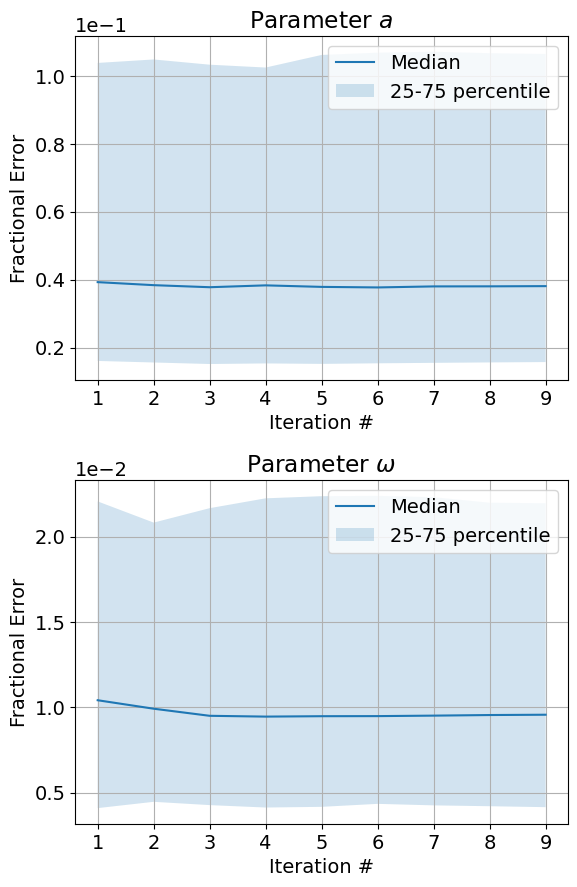

In [39]:
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

plt.rcParams.update({'font.size': 14})

def plot_errors_separate(error_dict, save=False, folder=''):
    # Group data by parameter
    param_data = defaultdict(list)
    for (run_id, (region_id, param)), values in error_dict.items():
        param_data[param].append(values)
    
    # Calculate statistics for each parameter
    param_stats = {}
    for param, data_list in param_data.items():
        data_array = np.array(data_list)
        param_stats[param] = {
            '25th': np.percentile(data_array, 25, axis=0),
            'median': np.median(data_array, axis=0),
            '75th': np.percentile(data_array, 75, axis=0)
        }
    
    # Create subplots
    num_params = len(param_stats)
    num_rows = (num_params + 1) // 1  # Round up to nearest integer
#     fig, axes = plt.subplots(num_rows, 2, figsize=(14, 3 * num_rows))
    fig, axes = plt.subplots(num_rows, 1, figsize=(6, 13))
    axes = axes.flatten()  # Flatten the axes array for easy indexing
    
    for i, (param, stats) in enumerate(param_stats.items()):
        ax = axes[i]
        x = np.arange(len(stats['median']))
        ax.plot(x, stats['median'], label='Median')
        ax.fill_between(x, stats['25th'], stats['75th'], alpha=0.2, label='25-75 percentile')
        ax.set_xticks(x)
        ax.set_xticklabels(range(1, len(x) + 1))
        ax.set_xlabel('Iteration #')
        ax.set_ylabel('Fractional Error')
        ax.set_title(f'Parameter ${param}$' if param != 'omega' else f'Parameter $\{param}$')
        ax.legend()
        ax.grid(True)
        ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    
    # Remove any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    if save:
        plt.savefig(f'./figures/{folder}_params.pdf', dpi=600, bbox_inches='tight')
    plt.show()

plot_errors_separate(res_mean, save, folder)

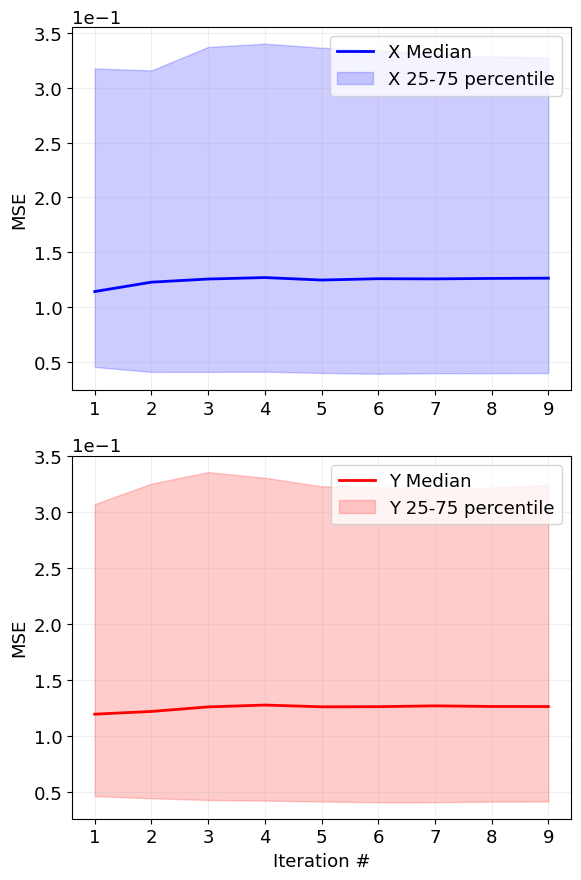

In [40]:
###### import matplotlib.pyplot as plt
import numpy as np
plt.rcParams.update({'font.size': 13})
def plot_twin_results(results_E, results_I, save=False, folder=''):
    def calculate_stats(data):
        # Flatten the data structure
        all_errors = [errors[1:] for run in data.values() for errors in run.values()]
        all_errors = np.array(all_errors)
        
        return {
            'median': np.median(all_errors, axis=0),
            '25th': np.percentile(all_errors, 25, axis=0),
            '75th': np.percentile(all_errors, 75, axis=0)
        }

    stats_E = calculate_stats(results_E)
    stats_I = calculate_stats(results_I)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 9))
    x = np.arange(len(stats_E['median']))

    # Plot data for results_E
    ax1.plot(x, stats_E['median'], 'b-', linewidth=2, label='X Median')
    ax1.fill_between(x, stats_E['25th'], stats_E['75th'], alpha=0.2, color='b', label='X 25-75 percentile')

    # Plot data for results_I
    ax2.plot(x, stats_I['median'], 'r-', linewidth=2, label='Y Median')
    ax2.fill_between(x, stats_I['25th'], stats_I['75th'], alpha=0.2, color='r', label='Y 25-75 percentile')

    # Set labels
    ax2.set_xlabel('Iteration #')
    ax1.set_ylabel('MSE')
    ax2.set_ylabel('MSE')

    # Add legends
    ax1.legend(loc='upper right')
    ax2.legend(loc='upper right')

    # Add grid
    ax1.grid(True, which="both", ls="-", alpha=0.2)
    ax2.grid(True, which="both", ls="-", alpha=0.2)

    # Set x-ticks
    ax1.set_xticks(x)
    ax2.set_xticks(x)
    ax1.set_xticklabels(range(1, len(x) + 1))
    ax2.set_xticklabels(range(1, len(x) + 1))

    # Set y-axis format
    ax1.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax2.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

    plt.tight_layout()
    if save: 
        plt.savefig(f'./figures/{folder}_errors.pdf', dpi=600, bbox_inches='tight')
    plt.show()


plot_twin_results(results_E, results_I, save, folder)